## Changing Absorption Line Profiles with OutLines to Have Same Column Densities

If `OutLines` is not installed, this can be done using `pip install SpecOutLines` in terminal or directly below. Using `pip` will automatically handle any dependencies. Detailed documentation is available at https://github.com/sflury/OutLines

In [2]:
%pip install SpecOutLines

mambajs 0.19.13

Process pip requirements ...

Requirement numpy already satisfied.
Requirement scipy already satisfied.
Requirement matplotlib already satisfied.


Start by importing the `OutLines` code and related basic packages.

In [3]:
import OutLines as OL
import numpy as np
import matplotlib.pyplot as plt

As before, let's start by instantiating an `OutLines.Profile` object for our model.

In [4]:
wave = np.array([1548.204,1550.784])
fosc = np.array([0.19,0.0952])
model = OL.Absorption(wave,fosc,VelocityField='VelPlaw',DensityProfile='Normal')
model.update_params(['TerminalVelocity','VelocityIndex'],[7000,0.5])
model.update_params(['Width'],[0.1])
model.update_params(['LogColumnOutflow1','LogColumnOutflow2'],[17,17])

Here is an example for setting the column densities of each transition equal to one another for fitting and plotting. This should be done (and only done!) for features arising from the same ion species. Below simply updates the `model` object instantiated from the `OutLines.Profile` class to update key parts of the model and fix the column densities.

In [5]:
from types import MethodType
from numpy import array,nansum,log
# return a profile assuming all column densities are the same
# as the first column density
def Profile_sameColumns(self,wave,*pars):
    pars = array(pars)
    logN = pars[2]
    pars[2:2+self.nLines] = logN
    return self.Profile(wave,*pars)
# convenience function
def get_profile(self,wave):
    return self.Profile_sameColumns(wave,*self.get_params())
# return a log likelihood for identical column densities
def log_likelihood(self,theta,x,y,yerr):
    ybar = self.Profile_sameColumns(x,*theta)
    ln_prb = -((y-ybar)/yerr)**2 - 2*log(yerr)
    return nansum(ln_prb)
# add the new profile function
model.Profile_sameColumns = MethodType(Profile_sameColumns,model)
# new get_profile
model.get_profile = MethodType(get_profile,model)
# set the new likelihood function
model.log_likelihood = MethodType(log_likelihood,model)

First, we need to check that everything works as intended! We can do this 
by plotting the line profile with and without the profile with and without
the correction we added.

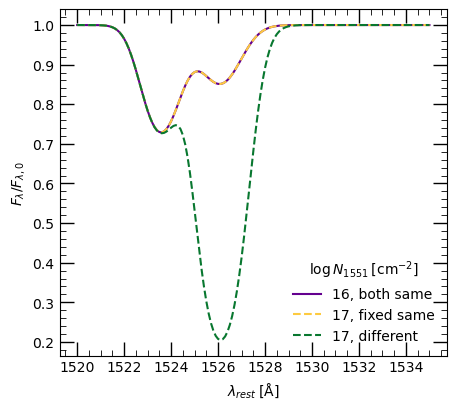

In [10]:
# set column densities to the same
model.update_params(['LogColumnOutflow1','LogColumnOutflow2'],[16,16])
# plot for reference
w = np.linspace(1520,1535,151)
plt.plot(w,model.get_profile(w),label='16, both same')
# a sanity check -- make the second column density higher
model.update_params(['LogColumnOutflow1','LogColumnOutflow2'],[16,17])
# plot to compare -- should be the same!
plt.plot(w,model.get_profile(w),ls='--',label='17, fixed same')
# plot unfixed version -- should be different!
plt.plot(w,model.Profile(w,*model.get_params()),ls='--',label='17, different')
plt.xlabel(r'$\lambda_{rest}\rm\:[\AA]$')
plt.ylabel(r'$F_\lambda/F_{\lambda,0}$')
plt.legend(title=r'$\log N_{1551}\rm\:[cm^{-2}]$',loc=4,frameon=False)
plt.show()

As you can see, the new function `Profile_sameColumn` fixes the second line, C IV $\lambda 1551$, to share the same column density as C IV $\lambda 1548$ even after we've updated the parameters to disagree. But the original `Profile` does not include this correction.